## Step 1: Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split ,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix ,classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve
import dataframe_image as dfi


## Step 2: Load the Dataset

In [2]:
Loan_prediction_df = pd.read_csv('data/Loan_prediction.csv')
Loan_prediction_copy = Loan_prediction_df.copy()

## Step 3: Understand the Dataset

In [3]:
Loan_prediction_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# Shape of dataset
print("\nShape of Dataset:", Loan_prediction_df.shape)

# Column names
print("\nColumns in Dataset:\n")
print(Loan_prediction_df.columns)

# Check missing values
print("\nMissing Values:\n")
print(Loan_prediction_df.isna().sum())

# Target values
print("\nTarget Values:")
print(Loan_prediction_df['Loan_Status'].value_counts())


Shape of Dataset: (614, 13)

Columns in Dataset:

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

Missing Values:

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Target Values:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [5]:
Loan_prediction_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [6]:
Loan_prediction_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
# check for duplicates
Loan_prediction_df.duplicated().sum()

np.int64(0)

## Step 4: EDA

Feature Cleaning

In [8]:
Loan_prediction_df.drop('Loan_ID', axis=1, inplace=True)

Target Distribution:

To check class imbalance.

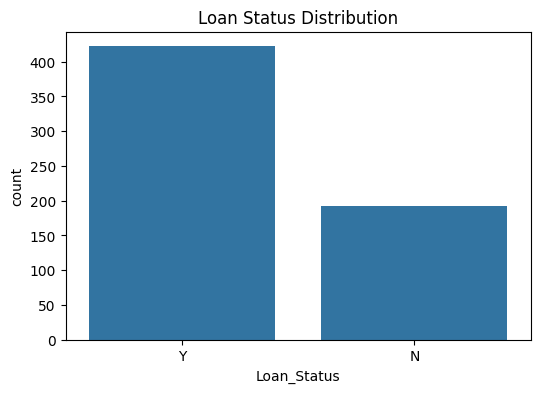

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=Loan_prediction_df)
plt.title('Loan Status Distribution')
plt.savefig('Images/loan_status_distribution.png')
plt.show()

Numerical Distributions:

In [10]:
num_cols = ['LoanAmount',
            'Loan_Amount_Term',
            'Credit_History',
            'ApplicantIncome',
            'CoapplicantIncome']

for col in num_cols:
    Loan_prediction_df[col] = Loan_prediction_df[col].fillna(Loan_prediction_df[col].median())

In [11]:
for col in num_cols:

    plt.figure(figsize=(6,4))
    sns.histplot(Loan_prediction_df[col], kde=True)

    plt.title(col)
    # plt.show()
    plt.savefig(f'Images/{col}_distribution.png')
    plt.close()

In [12]:
for col in num_cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x= Loan_prediction_df[col])

    plt.title(f'{col} Boxplot')
    # plt.show()
    plt.savefig(f'Images/{col}_boxplot.png')
    plt.close()

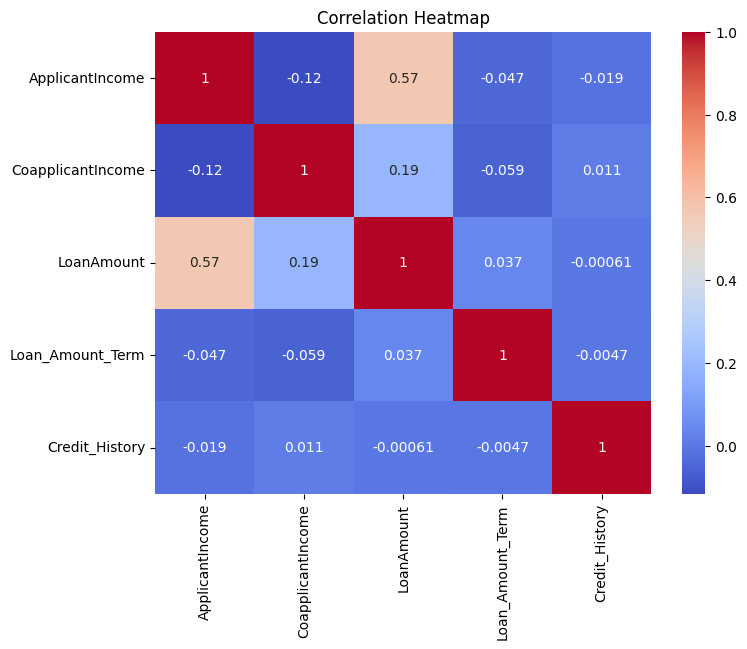

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    Loan_prediction_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.savefig('Images/correlation_heatmap.png')
plt.show()
plt.close()

In [14]:
cat_cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Dependents'
]

for col in cat_cols:
    Loan_prediction_df[col] = Loan_prediction_df[col].fillna(Loan_prediction_df[col].mode()[0])

In [15]:
Loan_prediction_df['Dependents'] = Loan_prediction_df['Dependents'].replace('3+', 3)
Loan_prediction_df['Dependents'] = pd.to_numeric(Loan_prediction_df['Dependents'])

Categorical vs Loan Status

In [16]:

for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        hue='Loan_Status',
        data=Loan_prediction_df
    )

    plt.savefig(f'Images/{col}_vs_LoanStatus.png')
    # plt.show()
    plt.close()

## Step 5: Define Features and Target Variable

Label encoding

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in Loan_prediction_df.select_dtypes( include=['object', 'string']).columns:
    Loan_prediction_df[col] = le.fit_transform(Loan_prediction_df[col])

In [18]:
# save cleaned dataset
Loan_prediction_df.to_csv('data/Loan_Prediction_Cleaned.csv',index=False)

In [19]:
X = Loan_prediction_df.drop('Loan_Status', axis=1)
Y = Loan_prediction_df['Loan_Status']

In [20]:
X.dtypes

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
dtype: object

In [21]:
Loan_prediction_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [22]:
Loan_prediction_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


In [23]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y # reduces the risk of biased performance estimates caused by uneven class distributions.
    # works for classification problems
)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 6: Model Building and evaluation

In [25]:
# resuable function to compare diff model

def evaluate_model(model,name,fitted=False):
    
    if not fitted:
        model.fit(X_train, Y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(Y_test, y_prob)

    plt.figure(figsize=(8,5))
    plt.plot(fpr, tpr)

    plt.plot([0,1],[0,1],'--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.savefig(f'Images/ROC_Curve_{name}.png')
    plt.show()
    
    scores = cross_val_score(
    model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy')

    print(scores)
    print(f"Mean CV Score of {name}:", scores.mean())

    print(f"Accuracy of {name}:", accuracy_score(Y_test,y_pred))
    print(f"Precision of {name}:", precision_score(Y_test,y_pred))
    print(f"Recall   of {name}:", recall_score(Y_test,y_pred))
    print(f"F1 Score of {name}:", f1_score(Y_test,y_pred))
    print(f"ROC AUC  of {name}:", roc_auc_score(Y_test,y_prob))

    # Create confusion matrix

    cm = confusion_matrix(Y_test, y_pred)

    # Visualize confusion matrix
    plt.figure(figsize=(6,4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title(f"Confusion Matrix of {name}")
    plt.savefig(f'Images/confusion_matrix_{name}.png')
    plt.show()
    plt.close()

    # Print classification report

    report = classification_report(Y_test, y_pred, target_names=['Not Approved', 'Approved'])

    print(f"Classification Report of {name}:\n")
    print(report)
    
    return {
    'Model': name,
    'CV Score': scores.mean(),
    'Accuracy': accuracy_score(Y_test, y_pred),
    'Precision': precision_score(Y_test, y_pred),
    'Recall': recall_score(Y_test, y_pred),
    'F1 Score': f1_score(Y_test, y_pred),
    'ROC AUC': roc_auc_score(Y_test, y_prob)
}

Logistic Regression

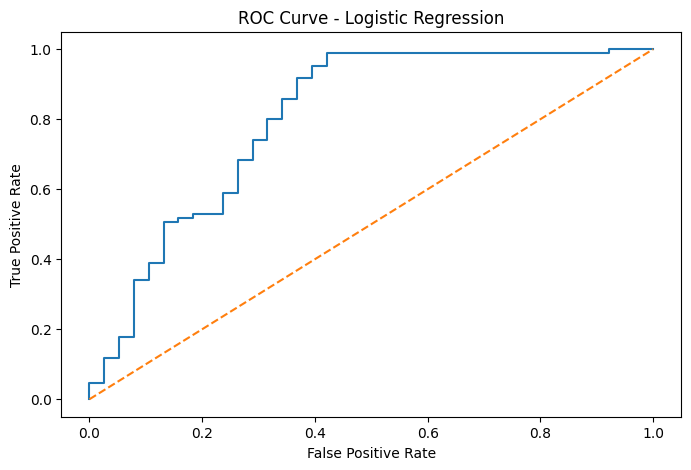

[0.7979798  0.80612245 0.81632653 0.78571429 0.7755102 ]
Mean CV Score of Logistic Regression: 0.7963306534735106
Accuracy of Logistic Regression: 0.8617886178861789
Precision of Logistic Regression: 0.84
Recall   of Logistic Regression: 0.9882352941176471
F1 Score of Logistic Regression: 0.9081081081081082
ROC AUC  of Logistic Regression: 0.8018575851393189


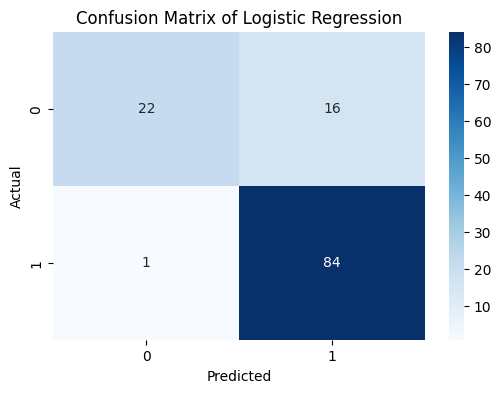

Classification Report of Logistic Regression:

              precision    recall  f1-score   support

Not Approved       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [26]:
lr = LogisticRegression()

# Normal model
lr_result = evaluate_model(lr, 'Logistic Regression')


Decision Tree

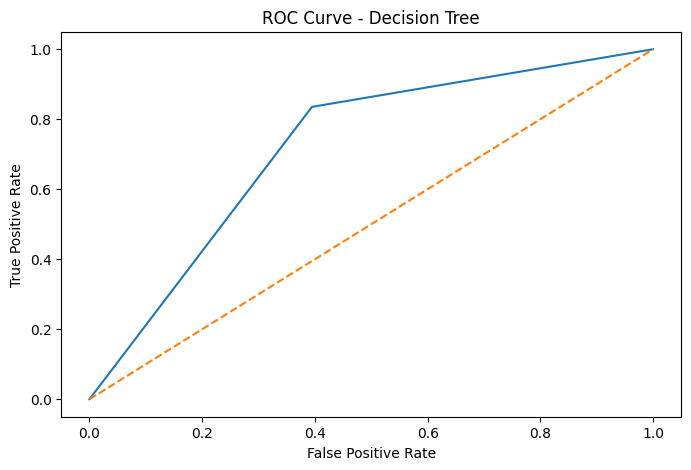

[0.6969697  0.69387755 0.70408163 0.65306122 0.69387755]
Mean CV Score of Decision Tree: 0.6883735312306741
Accuracy of Decision Tree: 0.7642276422764228
Precision of Decision Tree: 0.8255813953488372
Recall   of Decision Tree: 0.8352941176470589
F1 Score of Decision Tree: 0.8304093567251462
ROC AUC  of Decision Tree: 0.7202786377708978


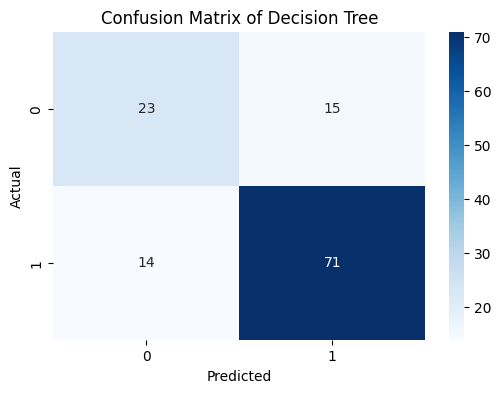

Classification Report of Decision Tree:

              precision    recall  f1-score   support

Not Approved       0.62      0.61      0.61        38
    Approved       0.83      0.84      0.83        85

    accuracy                           0.76       123
   macro avg       0.72      0.72      0.72       123
weighted avg       0.76      0.76      0.76       123



In [27]:
DT = DecisionTreeClassifier(random_state = 42)

# Normal model
dt_result = evaluate_model(DT, 'Decision Tree')

Random Forest

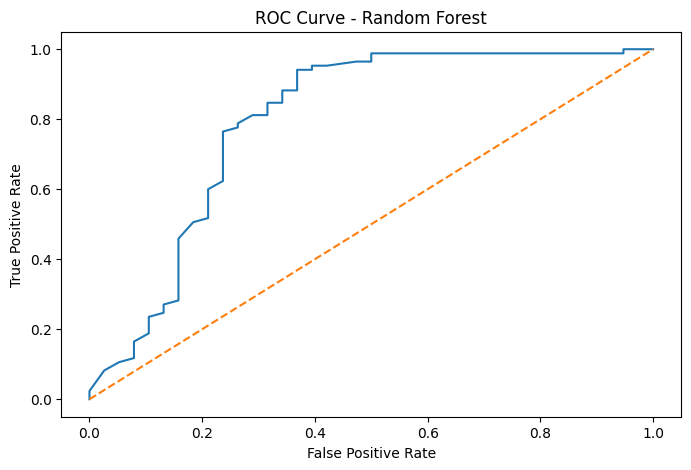

[0.75757576 0.79591837 0.80612245 0.75510204 0.76530612]
Mean CV Score of Random Forest: 0.7760049474335189
Accuracy of Random Forest: 0.8292682926829268
Precision of Random Forest: 0.8478260869565217
Recall   of Random Forest: 0.9176470588235294
F1 Score of Random Forest: 0.8813559322033898
ROC AUC  of Random Forest: 0.7959752321981425


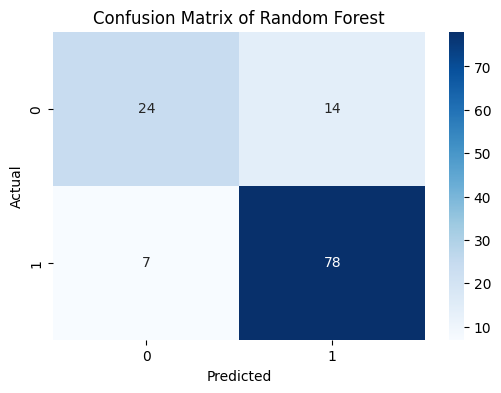

Classification Report of Random Forest:

              precision    recall  f1-score   support

Not Approved       0.77      0.63      0.70        38
    Approved       0.85      0.92      0.88        85

    accuracy                           0.83       123
   macro avg       0.81      0.77      0.79       123
weighted avg       0.83      0.83      0.82       123



In [28]:
rf = RandomForestClassifier(random_state=42)

# Normal model
rf_result = evaluate_model(rf, 'Random Forest')

Visualize Decision Tree

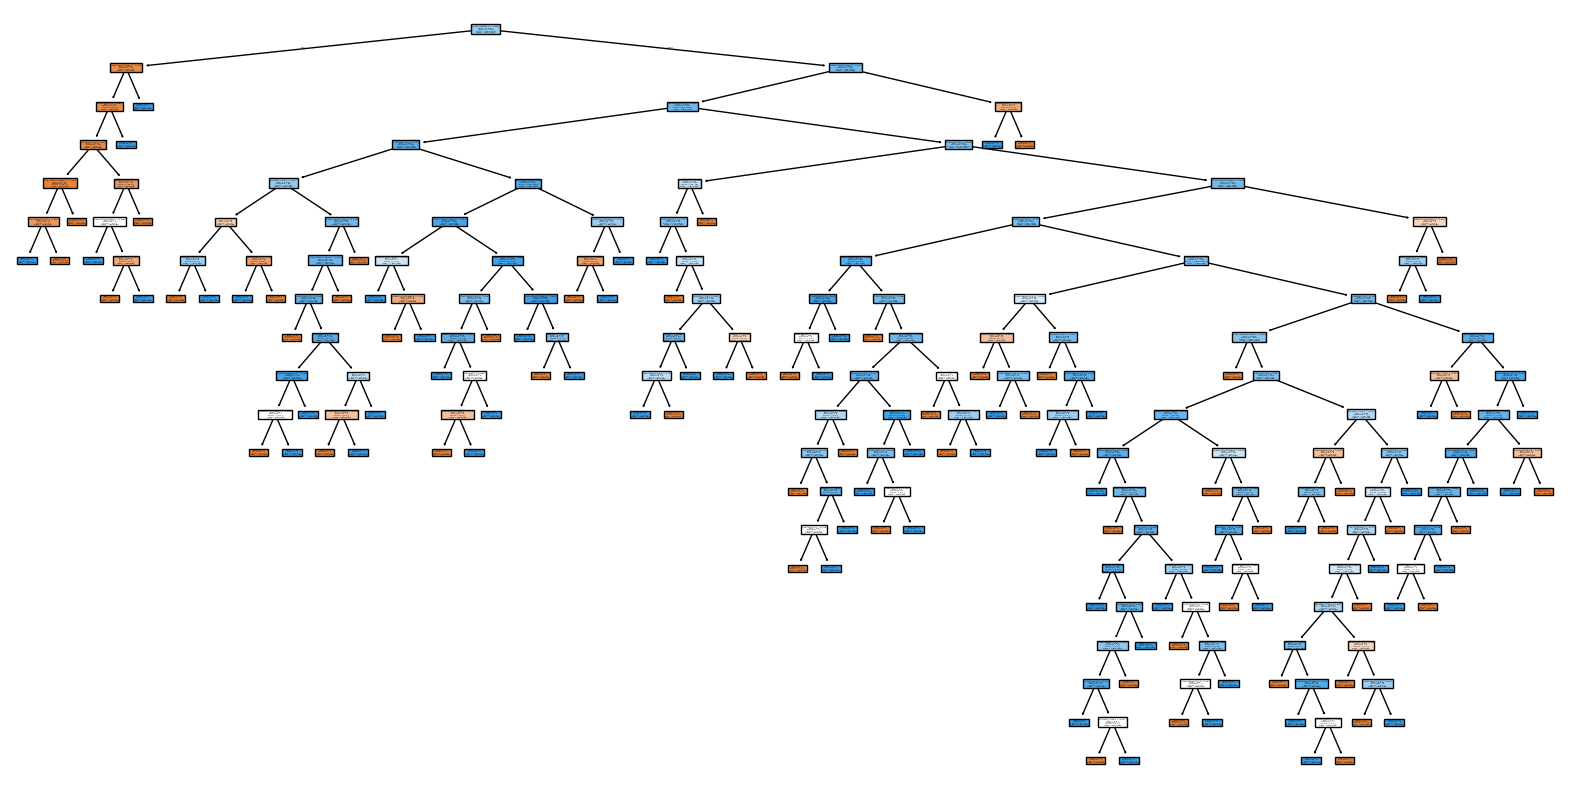

In [ ]:

plt.figure(figsize=(20,10))

plot_tree(
    DT,
    feature_names=X.columns,
    class_names=['Rejected','Approved'],
    filled=True
)

plt.savefig("Images/decision_tree.png")
plt.show()

Feature Importance

In [30]:
def feature_importance(model, name):

    if hasattr(model, 'coef_'):

        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Coefficient': model.coef_[0]
        })

        importance_df = importance_df.sort_values(
            by='Coefficient',
            ascending=False
        )

        print(f"\n{name}")
        print(importance_df)

        importance_df.plot(
            x='Feature',
            y='Coefficient',
            kind='bar',
            figsize=(10,5)
        )

    elif hasattr(model, 'feature_importances_'):

        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Coefficient': model.feature_importances_
        })

        importance_df = importance_df.sort_values(
            by='Coefficient',
            ascending=False
        )

        print(f"\n{name}")
        print(importance_df)

        importance_df.plot(
            x='Feature',
            y='Coefficient',
            kind='bar',
            figsize=(10,5)
        )

    else:
        print(f"{name} does not support feature importance.")
        return

    plt.title(f'{name} Feature Importance')
    plt.ylabel('Importance')
    plt.tight_layout()

    plt.savefig(f'Images/Feature_Importance_{name}.png')

    plt.show()
    plt.close()

    return importance_df


Logistic Regression
              Feature  Coefficient
9      Credit_History     1.232589
1             Married     0.258466
2          Dependents     0.114775
10      Property_Area     0.047412
8    Loan_Amount_Term     0.003615
5     ApplicantIncome    -0.007706
7          LoanAmount    -0.037753
4       Self_Employed    -0.072812
0              Gender    -0.090795
6   CoapplicantIncome    -0.150906
3           Education    -0.182466


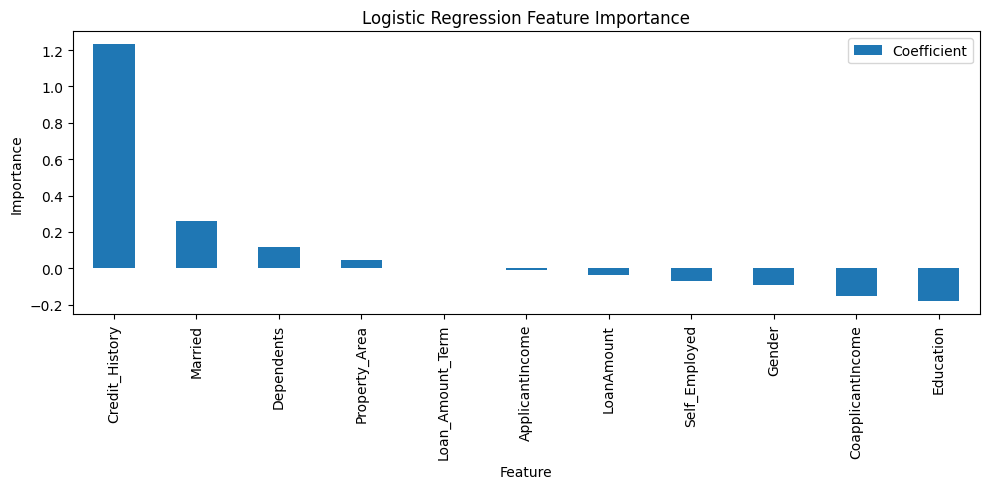


Decision Tree
              Feature  Coefficient
9      Credit_History     0.261446
7          LoanAmount     0.208105
5     ApplicantIncome     0.185021
6   CoapplicantIncome     0.133345
10      Property_Area     0.054374
2          Dependents     0.038936
8    Loan_Amount_Term     0.035406
3           Education     0.026743
1             Married     0.023589
0              Gender     0.022154
4       Self_Employed     0.010882


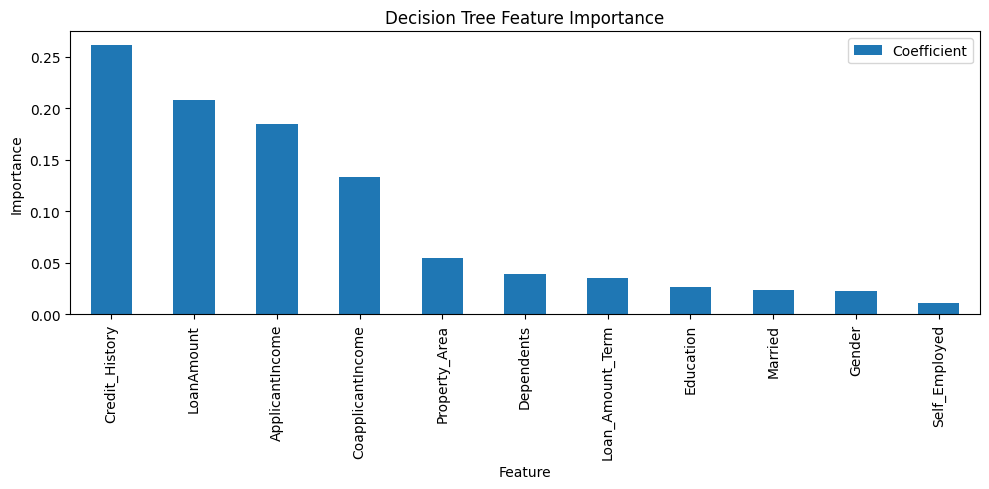


Random Forest
              Feature  Coefficient
9      Credit_History     0.242296
5     ApplicantIncome     0.209001
7          LoanAmount     0.192555
6   CoapplicantIncome     0.113800
2          Dependents     0.053360
10      Property_Area     0.048456
8    Loan_Amount_Term     0.048202
1             Married     0.027660
3           Education     0.027166
0              Gender     0.019237
4       Self_Employed     0.018267


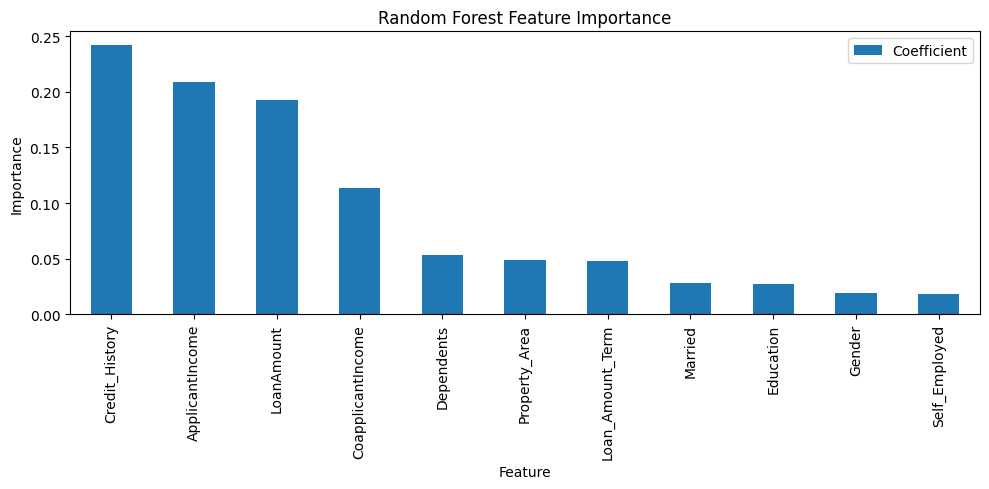

,Feature,Coefficient
9,Credit_History,0.242296
5,ApplicantIncome,0.209001
7,LoanAmount,0.192555
6,CoapplicantIncome,0.113800
2,Dependents,0.053360
10,Property_Area,0.048456
8,Loan_Amount_Term,0.048202
1,Married,0.027660
3,Education,0.027166
0,Gender,0.019237


In [31]:
feature_importance(lr,'Logistic Regression')
feature_importance(DT, 'Decision Tree')
feature_importance(rf, 'Random Forest')

Model Comparison Table

In [32]:
comparison_df = pd.DataFrame([
    lr_result,
    dt_result,
    rf_result
])

comparison_df

,Model,CV Score,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.796331,0.861789,0.840000,0.988235,0.908108,0.801858
1,Decision Tree,0.688374,0.764228,0.825581,0.835294,0.830409,0.720279
2,Random Forest,0.776005,0.829268,0.847826,0.917647,0.881356,0.795975


In [33]:
comparison_df.sort_values(
    by='ROC AUC',
    ascending=False
)

,Model,CV Score,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.796331,0.861789,0.840000,0.988235,0.908108,0.801858
2,Random Forest,0.776005,0.829268,0.847826,0.917647,0.881356,0.795975
1,Decision Tree,0.688374,0.764228,0.825581,0.835294,0.830409,0.720279


In [34]:
comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,CV Score,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.796331,0.861789,0.840000,0.988235,0.908108,0.801858
2,Random Forest,0.776005,0.829268,0.847826,0.917647,0.881356,0.795975
1,Decision Tree,0.688374,0.764228,0.825581,0.835294,0.830409,0.720279


In [35]:
comparison_df.to_csv(
    'data/Model_Comparison.csv',
    index=False
)

In [ ]:
styled_df = comparison_df.style.highlight_max(
    subset=[
        'CV Score',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ],
    color='red'
)

dfi.export(
    styled_df,
    "Images/Model_Comparison.png"
)

,Model,CV Score,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.796331,0.861789,0.840000,0.988235,0.908108,0.801858
1,Decision Tree,0.688374,0.764228,0.825581,0.835294,0.830409,0.720279
2,Random Forest,0.776005,0.829268,0.847826,0.917647,0.881356,0.795975


Conclusion

The objective of this project was to develop a machine learning model capable of predicting loan approval status based on applicant demographics, financial information, and credit history.

The dataset was first explored to understand its structure, identify missing values, and analyze feature distributions. Missing values in categorical variables were handled using mode imputation, while numerical variables were imputed using the median to reduce the influence of outliers. The Loan_ID column was removed as it did not contribute meaningful information for prediction. Categorical features were encoded into numerical values to make them suitable for machine learning algorithms.

Exploratory Data Analysis (EDA) revealed that ApplicantIncome, CoapplicantIncome, and LoanAmount were positively skewed and contained outliers. Credit_History emerged as the most influential feature affecting loan approval decisions. Feature importance analysis through Logistic Regression coefficients and tree-based models further confirmed the strong predictive power of Credit_History.

Three classification algorithms were implemented and compared:

Logistic Regression

Decision Tree Classifier

Random Forest Classifier





Model performance was evaluated using 5-Fold Cross Validation, Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.

| Model               | CV Score | Accuracy   | Precision  | Recall     | F1 Score   | ROC AUC   |
| ------------------- | -------- | ---------- | ---------- | ---------- | ---------- | --------- |
| Logistic Regression | 79.63%   | **86.18%** | 84.00%     | **98.82%** | **90.81%** | **0.802** |
| Decision Tree       | 68.84%   | 76.42%     | 82.56%     | 83.53%     | 83.04%     | 0.720     |
| Random Forest       | 77.60%   | 82.93%     | **84.78%** | 91.76%     | 88.14%     | 0.796     |


Based on the evaluation metrics, Logistic Regression was selected as the best-performing model for this dataset, providing the highest overall predictive performance while maintaining strong interpretability. The project successfully demonstrates a complete end-to-end machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, model building, evaluation, and model comparison.